# Generator Comparison

In [ ]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
from os import path, makedirs
from datetime import datetime
from functools import partial

# local imports
import sys
# sys.path.append('../../../')
sys.path.append('/exp/sbnd/app/users/munjung/xsec/freeze/cafpyana') # absolute path for running on EAF
from pyanalib.split_df_helpers import *
from analysis_village.numucc_1p0pi.variable_configs import VariableConfig
from analysis_village.numucc_1p0pi.utils import *
from analysis_village.numucc_1p0pi.files_config import *
from analysis_village.numucc_1p0pi.constants import *
from analysis_village.unfolding.wienersvd import *
from pyanalib.covariance import *

import matplotlib.pyplot as plt 

import warnings
from pandas.errors import PerformanceWarning
warnings.filterwarnings("ignore", category=PerformanceWarning)

In [3]:
save_fig = False
show_plot = True

save_fig_base_dir = "/exp/sbnd/data/users/munjung/plots/numucc1p0pi"
today_str = datetime.now().strftime("%Y%m%d")
save_fig_dir = path.join(save_fig_base_dir, f"generator_comparison-{today_str}")

if save_fig:
    if not path.exists(save_fig_dir):
        makedirs(save_fig_dir)
    print("saving plots in ", save_fig_dir)

# Cross section model comparisons

In [4]:
import awkward as ak

BRANCHES_NU_SIG = ["PDGnu", "cc", "Enu_true", "fScaleFactor", "Weight", "dpt", "dalphat", "dphit"]
BRANCHES_TRK_SIG = ["pdg", "px", "py", "pz", "E"]
BRANCHES_VTX_SIG = ["px_vert", "py_vert", "pz_vert"]


def _genie_trk_to_df(trk_arr):
    counts = ak.num(trk_arr["pdg"])
    n_ev = len(counts)
    event_ids = np.repeat(np.arange(n_ev), counts)
    subentry = ak.flatten(ak.unflatten(np.arange(ak.sum(counts)), counts))
    flat = ak.zip(
        {
            "event": event_ids,
            "subentry": subentry,
            **{c: ak.flatten(trk_arr[c]) for c in BRANCHES_TRK_SIG},
        }
    )
    return ak.to_dataframe(flat).set_index(["event", "subentry"])


def _genie_add_trk_counts(nudf, trkdf):
    """Match makedf mcnu: multiplicity counts use |pdg| and p thresholds; leading μ/p
    are highest-momentum FS particles (mcprim sort genE → last), not first listed track."""
    nudf = nudf.copy()
    trkdf = trkdf.copy()
    trkdf["_p"] = np.sqrt(trkdf.px**2 + trkdf.py**2 + trkdf.pz**2)
    for pid, pname, pth in zip([13, 2212, 211, 111], ["mu", "proton", "pi", "pi0"], [0.22, 0.3, 0.07, 0]):
        ntrks = trkdf[(np.abs(trkdf.pdg) == pid) & (trkdf._p > pth)].pdg.groupby(level=[0]).count()
        nudf[f"n{pname}s"] = ntrks.fillna(0)
        # Leading species: μ uses |pdg|; proton uses pdg==2212 (same as mc.p in makedf)
        species = trkdf[trkdf.pdg == pid] if pname == "proton" else trkdf[np.abs(trkdf.pdg) == pid]
        leading = species.sort_values("_p", ascending=False).groupby(level=[0]).head(1)
        leading_p = leading["_p"]
        leading_p.name = f"{pname}_p"
        nudf = nudf.join(leading_p.reset_index(level=[1])[f"{pname}_p"])

        leading_p_dir_z = leading.pz / leading_p
        leading_p_dir_z.name = f"{pname}_dir_z"
        nudf = nudf.join(leading_p_dir_z.reset_index(level=[1])[f"{pname}_dir_z"])
    return nudf


GENIE_FV_DET = "SBND_nohighyz"


def _genie_vtx_cm(nudf):
    return pd.DataFrame(
        {
            "x": nudf.vtx_x.to_numpy(dtype=float) * 100.0,
            "y": nudf.vtx_y.to_numpy(dtype=float) * 100.0,
            "z": nudf.vtx_z.to_numpy(dtype=float) * 100.0,
        }
    )


def _genie_numu_cc(nudf):
    return (nudf.PDGnu == 14) & (nudf.cc == 1)


def _genie_1mu_220(nudf):
    # mc.nmu_220MeVc == 1 (nmus counts |pdg|==13 with p > 0.22 GeV)
    return _genie_numu_cc(nudf) & (nudf.nmus == 1)


def _genie_mu_p_lt1(nudf):
    return _genie_1mu_220(nudf) & (nudf.mu_p < 1.0)


def _genie_1p_300(nudf):
    # mc.np_300MeVc == 1: exactly one proton above 0.3 GeV; lower-p protons allowed
    return _genie_mu_p_lt1(nudf) & (nudf.nprotons == 1)


def _genie_p_p_lt1(nudf):
    # mc.p.genp < 1 GeV on highest-momentum proton (proton_p from sort-by-p leading)
    return _genie_1p_300(nudf) & (nudf.proton_p < 1.0)


def _genie_no_pions(nudf):
    return (
        _genie_p_p_lt1(nudf)
        & (np.nan_to_num(nudf.npis, nan=0) == 0)
        & (np.nan_to_num(nudf.npi0s, nan=0) == 0)
    )


def _genie_flat_signal_mask(nudf):
    """GENIE flat 1p0π: topology only (no vertex FV)."""
    return _genie_no_pions(nudf)


# --- Production mcnu staged masks (mc_nu_df is vtx-FV pre-filtered in §Load production) ---
def _mc_mu_genp(nudf):
    return np.sqrt(
        nudf.mc.mu.genp.x**2 + nudf.mc.mu.genp.y**2 + nudf.mc.mu.genp.z**2
    )


def _mc_p_genp(nudf):
    return np.sqrt(nudf.mc.p.genp.x**2 + nudf.mc.p.genp.y**2 + nudf.mc.p.genp.z**2)


def _mc_numu_cc(nudf):
    return (nudf.mc.iscc == 1) & (nudf.mc.pdg == 14)


def _mc_1mu_220(nudf):
    return _mc_numu_cc(nudf) & (nudf.mc.nmu_220MeVc == 1)


def _mc_mu_p_lt1(nudf):
    return _mc_1mu_220(nudf) & (_mc_mu_genp(nudf) < 1.0)


def _mc_1p_300(nudf):
    return _mc_mu_p_lt1(nudf) & (nudf.mc.np_300MeVc == 1)


def _mc_p_p_lt1(nudf):
    return _mc_1p_300(nudf) & (_mc_p_genp(nudf) < 1.0)


def _mc_no_pions(nudf):
    return _mc_p_p_lt1(nudf) & (nudf.mc.npi_70MeVc == 0) & (nudf.mc.npi0 == 0)


# def _mc_vtx_fv(nudf):
#     """Re-apply vertex FV (redundant if mc_nu_df was pre-filtered)."""
#     return (
#         _mc_no_pions(nudf)
#         & InFV(nudf.mc.position, det=GENIE_FV_DET)
#         & (np.abs(nudf.mc.position.x) > FLAT_ALIGNED_X_CM)
#     )


# def _mc_per_tpc_ends(nudf):
#     return _mc_vtx_fv(nudf) & IsTruthCC1p0piPerTPCFV(nudf)


# def _mc_signal(nudf):
#     return _mc_vtx_fv(nudf)
#     # return IsNuInFV_NumuCC_1p0pi(nudf, signal_truth_fv=SIGNAL_TRUTH_FV)


In [5]:
def get_flatcaf_signals(genie_filename, var_name_list, bins_list):

    XSEC_ADD_FACTOR = 0.97

    n_list = {}
    for var_name, bins in zip(var_name_list, bins_list):

        events_sig = uproot.open(genie_filename + ":FlatTree_VARS")
        genie_nu_df = events_sig.arrays(BRANCHES_NU_SIG, library="pd")
        genie_vert = events_sig.arrays(BRANCHES_VTX_SIG, library="ak")
        genie_trk_df = _genie_trk_to_df(events_sig.arrays(BRANCHES_TRK_SIG, library="ak"))
        genie_nu_df = _genie_add_trk_counts(genie_nu_df, genie_trk_df)
        genie_nu_df["vtx_x"] = ak.fill_none(ak.firsts(genie_vert["px_vert"]), np.nan)
        genie_nu_df["vtx_y"] = ak.fill_none(ak.firsts(genie_vert["py_vert"]), np.nan)
        genie_nu_df["vtx_z"] = ak.fill_none(ak.firsts(genie_vert["pz_vert"]), np.nan)

        genie_sig = _genie_flat_signal_mask(genie_nu_df)
        genie_enu_sig = genie_nu_df.loc[genie_sig, var_name].to_numpy(dtype=float)
        if var_name == "dpt":
            genie_enu_sig = genie_enu_sig / 1e3

        if var_name == "dalphat":
            genie_enu_sig = np.rad2deg(genie_enu_sig)
        elif var_name == "dphit":
            genie_enu_sig = np.rad2deg(genie_enu_sig)

        genie_w_sig = (40.0 * genie_nu_df.loc[genie_sig, "fScaleFactor"] * genie_nu_df.loc[genie_sig, "Weight"]).to_numpy(dtype=float)

        # fig, ax = plt.subplots()

        centers = 0.5 * (bins[:-1] + bins[1:])
        bin_widths = np.diff(bins)

        # wgt_prod = np.ones_like(prod_enu_sig) * XSEC_UNIT * VERSION_CORRECTION
        # n, bins = np.histogram(prod_enu_sig, bins, weights=wgt_prod)
        # ax.hist(centers, bins=bins, histtype="step", weights=n/bin_widths, density=False, lw=2, label="Production signal")

        wgt_genie = genie_w_sig
        n, bins = np.histogram(genie_enu_sig, bins, weights=genie_w_sig)
        # print(n)
        # ax.hist(centers, bins=bins, histtype="step", weights=n/bin_widths, density=False, lw=2, ls="--", label="GENIE signal")
        # ax.set_xlabel(r"$E_\nu$ [GeV]")
        # ax.set_ylabel("Density")
        # ax.set_title(r"$\nu_\mu$ CC 1p0$\pi$ signal — truth $E_\nu$ shape")
        # ax.legend()
        # fig.tight_layout()
        # plt.show()

        n_list[var_name] = n * XSEC_ADD_FACTOR

    return n_list

In [6]:
# chi2_list = {
# "muon-p": 9.69,
# "muon-dir_z": 27.35,
# "proton-p": 18.08,
# "proton-dir_z": 13.67,
# "tki-del_Tp": 38.8,
# "tki-del_Tp_x": 28.7,
# "tki-del_Tp_y": 26.6,
# "tki-del_p": 33.6,
# "tki-del_alpha": 3.4,
# "tki-del_phi": 9.5,
# }

In [7]:
filename = "/pnfs/sbnd/persistent/users/apapadop/neut/bnb.sbnd.neut_6_1_4_numu_cc_gen1_flux.flat.root/neut.flat.root"
events_sig = uproot.open(filename + ":FlatTree_VARS")
genie_nu_df = events_sig.arrays(BRANCHES_NU_SIG, library="pd")
genie_vert = events_sig.arrays(BRANCHES_VTX_SIG, library="ak")
genie_trk_df = _genie_trk_to_df(events_sig.arrays(BRANCHES_TRK_SIG, library="ak"))
genie_nu_df = _genie_add_trk_counts(genie_nu_df, genie_trk_df)

In [8]:
var_names = ["dpt", "dalphat", "dphit", "mu_p", "proton_p", "mu_dir_z", "proton_dir_z"]
bins = [VariableConfig.tki_del_Tp().bins, 
        VariableConfig.tki_del_alpha().bins, 
        VariableConfig.tki_del_phi().bins,
        VariableConfig.muon_momentum().bins,
        VariableConfig.proton_momentum().bins,
        VariableConfig.muon_direction().bins,
        VariableConfig.proton_direction().bins]

filename = "/pnfs/sbnd/persistent/users/apapadop/neut/bnb.sbnd.neut_6_1_4_numu_cc_gen1_flux.flat.root/neut.flat.root"
neut_cache = get_flatcaf_signals(filename, var_names, bins)

filename = "/pnfs/sbnd/persistent/users/apapadop/GiBUU_Samples/GiBUU2025_patch5/gibuu2025_patch5_cc_numu_gen1_flux.root"
gibuu_cache = get_flatcaf_signals(filename, var_names, bins)

filename = "/exp/sbnd/data/users/munjung/xsec/GENIE_outputs/14_1000180400_CC_v3_6_0_SBN25_00a_00_000_SBND.flat.root"
sf_cache = get_flatcaf_signals(filename, var_names, bins)

filename = "/pnfs/sbnd/persistent/users/apapadop/nuwro/bnb.sbnd.nuwro_26_00_00_gen1_flux.flat.root"
nuwro_cache = get_flatcaf_signals(filename, var_names, bins)

In [9]:
filename = "/exp/sbnd/data/users/munjung/xsec/GENIE_outputs/14_1000180400_CC_v3_6_2_AR25_20i_01_000_SBND_gen1.flat.root"
AR25_20i_01_000_cache = get_flatcaf_signals(filename, var_names, bins)

filename = "/exp/sbnd/data/users/munjung/xsec/GENIE_outputs/14_1000180400_CC_v3_6_2_AR25_20i_01_001_SBND_gen1.flat.root"
AR25_20i_01_001_cache = get_flatcaf_signals(filename, var_names, bins)

filename = "/exp/sbnd/data/users/munjung/xsec/GENIE_outputs/14_1000180400_CC_v3_6_2_AR25_20i_02_000_SBND_gen1.flat.root"
AR25_20i_02_000_cache = get_flatcaf_signals(filename, var_names, bins)

filename = "/exp/sbnd/data/users/munjung/xsec/GENIE_outputs/14_1000180400_CC_v3_6_2_AR25_22i_00_000_SBND_gen1.flat.root"
AR25_22i_00_000_cache = get_flatcaf_signals(filename, var_names, bins)

In [10]:
filename = "/exp/sbnd/data/users/munjung/xsec/GENIE_outputs/14_1000180400_CC_v3_6_0-CRPA_G21_11a_00_000_SBND.flat.root"
CRPA_cache = get_flatcaf_signals(filename, var_names, bins)

filename = "/exp/sbnd/data/users/munjung/xsec/GENIE_outputs/14_1000180400_CC_v3_6_0-HF_G21_11a_00_000_SBND.flat.root"
HF_cache = get_flatcaf_signals(filename, var_names, bins)

# Measurement

In [11]:
# load unfold_cache from pickle file
outdir = "/exp/sbnd/data/users/munjung/xsec/RESULTS/DATA_RESULTS"
with open(os.path.join(outdir, "Gen1_unfold_cache_efielddet_noneutron.pkl"), "rb") as f:
    unfold_cache = pickle.load(f)

# Plot

In [75]:
# variable to plot
# var_config = VariableConfig.tki_del_Tp()
# genie_var_name = "dpt"
# bins = var_config.bins

# var_config = VariableConfig.tki_del_alpha()
# genie_var_name = "dalphat"
# bins = var_config.bins

var_config = VariableConfig.tki_del_phi()
genie_var_name = "dphit"
bins = var_config.bins

# var_config = VariableConfig.muon_momentum()
# genie_var_name = "mu_p"
# bins = var_config.bins

# var_config = VariableConfig.proton_momentum()
# genie_var_name = "proton_p"
# bins = var_config.bins

# var_config = VariableConfig.muon_direction()
# genie_var_name = "mu_dir_z"
# bins = var_config.bins

# var_config = VariableConfig.proton_direction()
# genie_var_name = "proton_dir_z"
# bins = var_config.bins

In [76]:
# plt.rcParams['figure.dpi'] = 300

In [77]:
save_fig = True
save_fig_dir

'/exp/sbnd/data/users/munjung/plots/numucc1p0pi/generator_comparison-20260605'

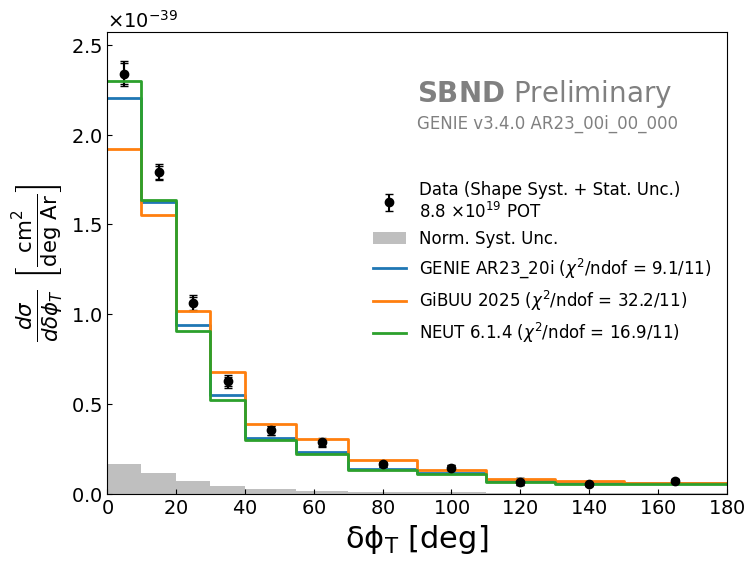

In [81]:
models = {"GENIE AR23_20i": [unfold_cache[var_config.var_save_name]["model"], "C0"],
          "GiBUU 2025": [gibuu_cache[genie_var_name] / 1000, "C1"],
          "NEUT 6.1.4": [neut_cache[genie_var_name] , "C2"]}
          # "SF": sf_cache[genie_var_name] ,
        #   "NuWro 26": [nuwro_cache[genie_var_name], "C3"] } #,  "AR23": nevts_dict["GENIE AR23"]}

xsec_unit = unfold_cache[var_config.var_save_name]["ret_signal_hists"]["nevts_allmc"] / models["GENIE AR23_20i"][0]
measured = unfold_cache[var_config.var_save_name]["measured"]
unfold = unfold_cache[var_config.var_save_name]["unfold"]

save_name = f"{save_fig_dir}/{var_config.var_save_name}-xsec_comparison-generators"
plot_unfolded_result(unfold, 
                    measured, 
                    models,
                    var_config,
                    xsec_unit=1/np.unique(xsec_unit)[0],
                    save_fig=save_fig, 
                    save_name=save_name,
                    textloc=[0.5, 0.9],
                    approval="preliminary",
                    data=True,
                    closure_test=False)

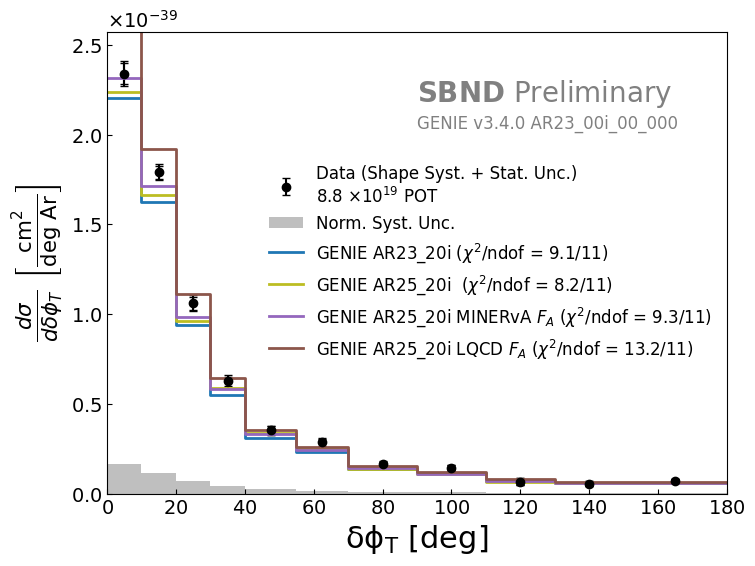

In [82]:
save_name = f"{save_fig_dir}/{var_config.var_save_name}-xsec_comparison-AR25"
models = {"GENIE AR23_20i": [unfold_cache[var_config.var_save_name]["model"], "C0"],
          "GENIE AR25_20i ": [AR25_20i_01_000_cache[genie_var_name], "C8"],
          "GENIE AR25_20i MINERvA $F_A$": [AR25_20i_01_001_cache[genie_var_name], "C4"],
          "GENIE AR25_20i LQCD $F_A$": [AR25_20i_02_000_cache[genie_var_name], "C5"]}
        #   "AR25_22i_00_000": AR25_22i_00_000_cache[genie_var_name]}

xsec_unit = unfold_cache[var_config.var_save_name]["ret_signal_hists"]["nevts_allmc"] / models["GENIE AR23_20i"][0]
measured = unfold_cache[var_config.var_save_name]["measured"]
unfold = unfold_cache[var_config.var_save_name]["unfold"]

plot_unfolded_result(unfold, 
                    measured, 
                    models,
                    var_config,
                    xsec_unit=1/np.unique(xsec_unit)[0],
                    save_fig=save_fig, 
                    save_name=save_name,
                    textloc=[0.5, 0.9],
                    approval="preliminary",
                    data=True,
                    closure_test=False)

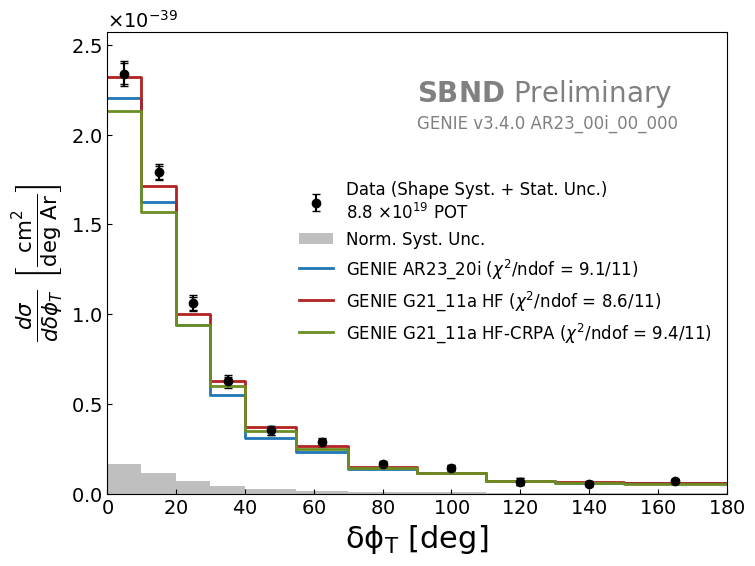

In [83]:
save_name = f"{save_fig_dir}/{var_config.var_save_name}-xsec_comparison-HF"
models = {"GENIE AR23_20i": [unfold_cache[var_config.var_save_name]["model"], "C0"],
          "GENIE G21_11a HF": [HF_cache[genie_var_name], "firebrick"],
          "GENIE G21_11a HF-CRPA": [CRPA_cache[genie_var_name], "olivedrab"]}

xsec_unit = unfold_cache[var_config.var_save_name]["ret_signal_hists"]["nevts_allmc"] / models["GENIE AR23_20i"][0]
measured = unfold_cache[var_config.var_save_name]["measured"]
unfold = unfold_cache[var_config.var_save_name]["unfold"]

plot_unfolded_result(unfold, 
                    measured, 
                    models,
                    var_config,
                    xsec_unit=1/np.unique(xsec_unit)[0],
                    save_fig=save_fig, 
                    save_name=save_name,
                    textloc=[0.5, 0.9],
                    approval="preliminary",
                    data=True,
                    closure_test=False)

In [84]:
save_fig_dir

'/exp/sbnd/data/users/munjung/plots/numucc1p0pi/generator_comparison-20260605'

In [50]:
plot_unfolded_result

<function analysis_village.numucc_1p0pi.utils.plot_unfolded_result(unfold, measured, models, var_config, chi2_list=[], chi2_dict={}, xsec_unit=0, textloc=[0.05, 0.55], approval='internal', plot_labels=['', '', ''], plot=True, save_fig=False, save_name=None, data=False, closure_test=False, model_add_smear=None)>

In [ ]:
xsec_unit

In [ ]:
1/np.unique(xsec_unit)[0]